# Phân tích Sentiment & Text Mining: Miu Lê Comments
Dựa trên yêu cầu phân tích Section A, B, và C. Dưới mỗi biểu đồ có phần giải thích chi tiết ý nghĩa của kết quả trực quan hóa.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
from collections import Counter
import re
import string
import warnings
warnings.filterwarnings('ignore')

# Cấu hình
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.figsize'] = (10, 6)

try:
    df = pd.read_csv('threads/miule_comments_sentiment.csv')
    if 'controversy' in df.columns:
        df['controversy'] = df['controversy'].astype(bool)
except Exception as e:
    print("Error loading data:", e)

color_map = {
    'positive': '#00CC96',
    'negative': '#EF553B',
    'neutral': '#636EFA',
    'mixed': '#FFA15A',
    'unknown': '#B6E880'
}


## SECTION A: OVERVIEW & DISTRIBUTIONS

In [2]:
# A. Sentiment Distribution
if 'sentiment' in df.columns:
    sentiment_counts = df['sentiment'].value_counts()
    fig = px.pie(
        values=sentiment_counts.values, 
        names=sentiment_counts.index, 
        title='A. Phân bố cảm xúc tổng quan (Sentiment Distribution)',
        hole=0.4,
        color=sentiment_counts.index,
        color_discrete_map=color_map
    )
    fig.update_traces(textposition='inside', textinfo='percent+label')
    fig.show()


**Ý nghĩa biểu đồ:**
Biểu đồ tròn (Donut chart) này cung cấp cái nhìn tổng quan nhất về thái độ của cộng đồng mạng. Nó cho biết tỷ lệ phần trăm các bình luận theo từng nhóm sắc thái cảm xúc (Tích cực, Tiêu cực, Trung lập,...). Qua đó, bạn có thể nhận định nhanh chóng phản ứng của công chúng đang nghiêng về hướng ủng hộ, phản đối hay chỉ đơn thuần là quan sát.


In [3]:
# A. Emotion Distribution
if 'emotion' in df.columns:
    emotion_counts = df['emotion'].value_counts().head(12)
    fig = px.bar(
        x=emotion_counts.values, 
        y=emotion_counts.index, 
        orientation='h',
        title='A. Emotion xuất hiện nhiều nhất',
        labels={'x': 'Count', 'y': 'Emotion'},
        color=emotion_counts.values,
        color_continuous_scale='Magma'
    )
    fig.update_layout(yaxis={'categoryorder':'total ascending'})
    fig.show()


**Ý nghĩa biểu đồ:**
Biểu đồ cột ngang thống kê tần suất của các trạng thái cảm xúc (Emotion) cụ thể. Trong khi Sentiment chỉ phân chia sơ bộ (Tích cực/Tiêu cực), thì biểu đồ này giúp đi sâu hơn vào nội tâm người dùng: họ đang vui vẻ, tức giận, hài hước, hay thất vọng. Sự phân bố này giúp xác định "sắc thái cảm xúc chủ đạo" trong các cuộc thảo luận.


In [4]:
# A. Topic Distribution
if 'topic' in df.columns:
    topic_counts = df['topic'].value_counts().head(12)
    fig = px.treemap(
        names=topic_counts.index,
        parents=[""]*len(topic_counts),
        values=topic_counts.values,
        title='A. Topic được nhắc nhiều',
        color=topic_counts.values,
        color_continuous_scale='Blues'
    )
    fig.show()


**Ý nghĩa biểu đồ:**
Biểu đồ Treemap thể hiện độ lớn của các chủ đề (Topic) được bàn luận. Các ô có diện tích lớn cho thấy chủ đề đó đang thu hút sự chú ý nhiều nhất (ví dụ: diễn xuất, đời tư, âm nhạc,...). Điều này giúp chỉ ra chính xác cộng đồng đang tập trung sự quan tâm vào khía cạnh nào khi nhắc đến đối tượng.


In [5]:
# A. Controversy Distribution
if 'controversy' in df.columns:
    controversy_counts = df['controversy'].value_counts()
    controversy_rate = (controversy_counts.get(True, 0) / len(df)) * 100

    fig = go.Figure(go.Indicator(
        mode = "gauge+number",
        value = controversy_rate,
        title = {'text': "A. Tỷ lệ tranh cãi (Controversy Rate %)"},
        gauge = {
            'axis': {'range': [0, 100]},
            'bar': {'color': "#EF553B"},
            'steps': [
                {'range': [0, 30], 'color': "lightgray"},
                {'range': [30, 70], 'color': "gray"}
            ]
        }
    ))
    fig.show()


**Ý nghĩa biểu đồ:**
Biểu đồ đồng hồ đo (Gauge indicator) này hiển thị tỷ lệ phần trăm các bình luận có tính chất gây tranh cãi (chứa ngôn từ gay gắt, châm biếm hoặc đối đầu). Tỷ lệ này là một chỉ số rủi ro truyền thông: nếu chỉ số này cao, chứng tỏ chủ đề đang rất nhạy cảm và cộng đồng đang có sự chia rẽ sâu sắc.


## SECTION B: CROSS-ANALYSIS

In [6]:
# B. Topic x Sentiment
if 'topic' in df.columns and 'sentiment' in df.columns:
    top_topics = df['topic'].value_counts().head(10).index
    topic_sentiment = pd.crosstab(df[df['topic'].isin(top_topics)]['topic'], df['sentiment'], normalize='index') * 100

    fig = px.bar(
        topic_sentiment.reset_index(),
        x='topic',
        y=topic_sentiment.columns,
        title='B. Sentiment rate theo Topic (Topic nào tiêu cực cao)',
        labels={'value': 'Percentage (%)', 'topic': 'Topic', 'sentiment': 'Sentiment'},
        color_discrete_map=color_map
    )
    fig.update_layout(barmode='stack')
    fig.show()


**Ý nghĩa biểu đồ:**
Biểu đồ cột chồng (Stacked Bar Chart) thể hiện cấu trúc cảm xúc chi tiết bên trong mỗi chủ đề. Phân tích này giúp trả lời câu hỏi: "Người ta đang chê bai điều gì và khen ngợi điều gì?". Ví dụ, nếu chủ đề "ngoại hình" có sắc màu xanh (tích cực) chiếm ưu thế nhưng chủ đề "đời tư" lại chủ yếu là màu đỏ (tiêu cực), bạn sẽ có cái nhìn cụ thể hơn về nguyên nhân dẫn đến các phản ứng đó.


In [7]:
# B. Emotion x Controversy
if 'emotion' in df.columns and 'controversy' in df.columns:
    emotion_controversy = df.groupby('emotion')['controversy'].mean().sort_values(ascending=False).head(10) * 100
    fig = px.bar(
        x=emotion_controversy.values,
        y=emotion_controversy.index,
        orientation='h',
        title='B. Emotion liên quan tranh cãi (Controversy rate theo emotion)',
        labels={'x': 'Controversy Rate (%)', 'y': 'Emotion'},
        color=emotion_controversy.values,
        color_continuous_scale='Reds'
    )
    fig.update_layout(yaxis={'categoryorder':'total ascending'})
    fig.show()


**Ý nghĩa biểu đồ:**
Biểu đồ này đánh giá mức độ tương quan giữa cảm xúc cụ thể và yếu tố gây tranh cãi. Những thanh ngang dài nhất cho thấy các bình luận mang cảm xúc đó thường châm ngòi cho những cuộc cãi vã lớn. Điều này giúp xác định những cảm xúc có tính "dễ cháy" nhất trên không gian mạng.


In [8]:
# B. Topic x Controversy
if 'topic' in df.columns and 'controversy' in df.columns:
    topic_controversy = df.groupby('topic')['controversy'].mean().sort_values(ascending=False).head(10) * 100
    fig = px.bar(
        x=topic_controversy.values,
        y=topic_controversy.index,
        orientation='h',
        title='B. Topic gây tranh luận (Controversy rate theo topic)',
        labels={'x': 'Controversy Rate (%)', 'y': 'Topic'},
        color=topic_controversy.values,
        color_continuous_scale='Oranges'
    )
    fig.update_layout(yaxis={'categoryorder':'total ascending'})
    fig.show()


**Ý nghĩa biểu đồ:**
Biểu đồ này tìm ra các "điểm nóng" (hot button topics). Những chủ đề nằm ở phần đỉnh của biểu đồ chính là nguyên nhân tạo ra sự chia rẽ và tranh luận gay gắt. Nhờ đó, người phân tích có thể biết nên né tránh (hoặc xử lý khéo léo) những chủ đề nhạy cảm nào trong tương lai.


## SECTION C: TEXT ANALYSIS

In [9]:
# Text Processing Setup
try:
    from pyvi import ViTokenizer
except ImportError:
    print("Vui lòng cài đặt pyvi: !pip install pyvi")

import string
import re
import urllib.request
import os

# Tải danh sách stopword tiếng Việt đầy đủ (nếu chưa có)
stopword_file = 'vietnamese-stopwords.txt'
if not os.path.exists(stopword_file):
    try:
        url = "https://raw.githubusercontent.com/stopwords/vietnamese-stopwords/master/vietnamese-stopwords.txt"
        urllib.request.urlretrieve(url, stopword_file)
    except Exception as e:
        print("Không thể tải stopword:", e)

# Đọc stopwords từ file
stopwords_vn = set()
if os.path.exists(stopword_file):
    with open(stopword_file, 'r', encoding='utf-8') as f:
        for line in f:
            word = line.strip().replace(' ', '_')
            if word:
                stopwords_vn.add(word)

# Bổ sung danh sách từ rác/vô nghĩa đặc thù trên mạng xã hội
user_custom_stopwords = {
    "là", "và", "thì", "mà", "đó", "này", "đấy", "rồi", "nha", "ha", "ờ", "ừ", 
    "à", "ơ", "ê", "ừm", "vậy", "nếu", "sao", "xong", "giờ", "kiểu", "cái", "còn", 
    "đến", "đi", "được", "người", "bạn", "tụi", "tụi_mày", "mấy", "một", "hai", 
    "ba", "đang", "nữa", "quá", "thật", "rất", "luôn", "chỉ", "nên", "cũng", 
    "với", "cho", "trong", "ngoài", "về", "khi", "lúc", "tại", "do", "có", "bị", 
    "làm", "thấy", "biết", "nghe", "xem", "nói", "đọc", "ơi", "con", "ổng", "bả", 
    "ảnh", "chị", "anh", "em", "tao", "mày", "tui", "t", "tụi_bây",
    "nhá", "ạ", "á", "hả", "kìa", "của"
}
stopwords_vn.update(user_custom_stopwords)

def clean_text(text):
    if not isinstance(text, str):
        return []
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    
    try:
        text = ViTokenizer.tokenize(text)
    except NameError:
        pass
        
    words = text.split()
    words = [w for w in words if w not in stopwords_vn and len(w) > 1]
    return words

df['cleaned_words'] = df['comment_text'].apply(clean_text)
all_words = [word for words in df['cleaned_words'] for word in words]


In [10]:
# C. Word Count Overview
total_words = len(all_words)
unique_words = len(set(all_words))
avg_length = df['cleaned_words'].apply(len).mean()

fig = go.Figure()

fig.add_trace(go.Indicator(
    mode = "number",
    value = total_words,
    title = {"text": "Total Words"},
    domain = {'row': 0, 'column': 0}
))

fig.add_trace(go.Indicator(
    mode = "number",
    value = unique_words,
    title = {"text": "Unique Words"},
    domain = {'row': 0, 'column': 1}
))

fig.add_trace(go.Indicator(
    mode = "number",
    value = avg_length,
    title = {"text": "Avg Words/Comment", "font": {"size": 18}},
    number = {"valueformat": ".1f"},
    domain = {'row': 0, 'column': 2}
))

fig.update_layout(
    grid = {'rows': 1, 'columns': 3, 'pattern': "independent"},
    title="C. Tổng quan Corpus",
    height=300
)
fig.show()


**Ý nghĩa biểu đồ:**
Các thẻ KPI tổng quát cung cấp thông tin số liệu cơ bản về lượng ngôn từ được sử dụng:
- **Total Words**: Tổng số từ ngữ đã trải qua quá trình làm sạch. Thể hiện quy mô của tập dữ liệu.
- **Unique Words**: Số lượng từ vựng độc nhất. Con số lớn cho thấy sự đa dạng của ngôn ngữ được cộng đồng sử dụng.
- **Avg Words/Comment**: Độ dài trung bình của mỗi bình luận. Bình luận có nhiều từ thường chứa nhiều bối cảnh, luận điểm và mang ý nghĩa cảm xúc phức tạp hơn là một bình luận ngắn.


In [11]:
# C. Top Word Frequency
word_counts = Counter(all_words)
top_words = dict(word_counts.most_common(20))

fig = px.bar(
    x=list(top_words.values()),
    y=list(top_words.keys()),
    orientation='h',
    title='C. Từ xuất hiện nhiều (Top Word Frequency)',
    labels={'x': 'Frequency', 'y': 'Word'},
    color=list(top_words.values()),
    color_continuous_scale='Teal'
)
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()


**Ý nghĩa biểu đồ:**
Biểu đồ này xếp hạng top các từ đơn được sử dụng nhiều nhất (sau khi đã loại trừ các từ không mang ý nghĩa rõ ràng/stop-words). Việc liệt kê này giúp bạn phát hiện ra các từ khoá trọng tâm nhất, là cốt lõi của nội dung mà đám đông liên tục nhắc đến.


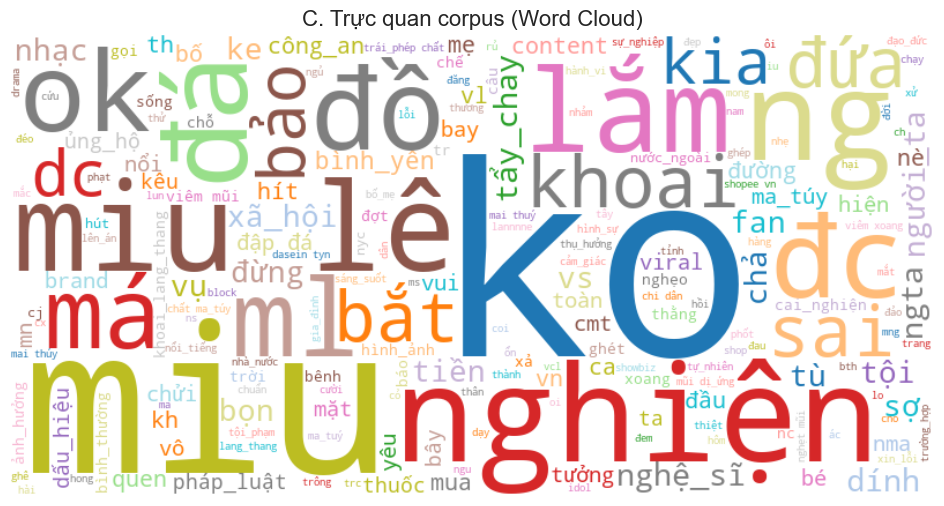

In [12]:
# C. Word Cloud
try:
    from wordcloud import WordCloud
    text_for_cloud = " ".join(all_words)
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='tab20').generate(text_for_cloud)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title('C. Trực quan corpus (Word Cloud)', fontsize=16)
    plt.show()
except ImportError:
    print("WordCloud chưa được cài đặt. Có thể chạy lệnh: !pip install wordcloud")


**Ý nghĩa biểu đồ:**
Đám mây từ vựng (Word Cloud) là cách tiếp cận trực quan nhất để tóm tắt một văn bản lớn. Từ nào xuất hiện càng thường xuyên, kích thước font chữ của nó càng lớn. Nhờ đó, người xem có thể lập tức "chụp" được ý chính của các cuộc thảo luận mà không cần phải đối chiếu với các bảng số liệu khô khan.


In [13]:
# C. Bigram Analysis
try:
    from sklearn.feature_extraction.text import CountVectorizer

    corpus_for_bigram = df['cleaned_words'].apply(lambda x: ' '.join(x))
    vectorizer = CountVectorizer(ngram_range=(2, 2))
    X = vectorizer.fit_transform(corpus_for_bigram)
    
    bigram_counts = pd.DataFrame(
        {'bigram': vectorizer.get_feature_names_out(), 'count': X.sum(axis=0).A1}
    ).sort_values(by='count', ascending=False).head(15)

    fig = px.bar(
        bigram_counts,
        x='count',
        y='bigram',
        orientation='h',
        title='C. Phân tích cụm từ (Bigram Analysis)',
        labels={'count': 'Frequency', 'bigram': 'Bigram'},
        color='count',
        color_continuous_scale='Purples'
    )
    fig.update_layout(yaxis={'categoryorder':'total ascending'})
    fig.show()
except ImportError:
    print("Scikit-learn chưa được cài đặt. Có thể chạy lệnh: !pip install scikit-learn")


**Ý nghĩa biểu đồ:**
Phân tích cụm từ (Bigram) khắc phục nhược điểm của việc phân tích từ đơn vì đôi khi đứng riêng lẻ thì từ ngữ không có nghĩa đặc thù. Bigram đi tìm các "cặp 2 từ" thường xuyên đi liền nhau trong một ngữ cảnh. Nó giúp làm nổi bật các khái niệm, thành ngữ hay ý định hoàn chỉnh thay vì những từ vựng rời rạc.


In [14]:
# C. Sentiment Word Analysis
pos_words = [word for words in df[df['sentiment'] == 'positive']['cleaned_words'] for word in words]
neg_words = [word for words in df[df['sentiment'] == 'negative']['cleaned_words'] for word in words]

top_pos = dict(Counter(pos_words).most_common(10))
top_neg = dict(Counter(neg_words).most_common(10))

fig = make_subplots(rows=1, cols=2, subplot_titles=("Top Words (Positive)", "Top Words (Negative)"))

fig.add_trace(
    go.Bar(x=list(top_pos.values())[::-1], y=list(top_pos.keys())[::-1], orientation='h', marker_color='#00CC96', name="Positive"),
    row=1, col=1
)

fig.add_trace(
    go.Bar(x=list(top_neg.values())[::-1], y=list(top_neg.keys())[::-1], orientation='h', marker_color='#EF553B', name="Negative"),
    row=1, col=2
)

fig.update_layout(
    title='C. Từ theo sentiment (Sentiment Word Analysis)',
    showlegend=False,
    height=500
)
fig.show()


**Ý nghĩa biểu đồ:**
Sự đối chiếu thông qua hai biểu đồ phụ (Subplots) giúp so sánh trực tiếp "ngôn ngữ" của hai thái cực: Nhóm ủng hộ (Tích cực) so với Nhóm phản đối (Tiêu cực). Qua đó, bạn hiểu rõ cách mà từng nhóm tiếp cận chủ đề (họ dùng từ ngữ gì để khen ngợi và sử dụng ngôn từ thế nào khi chỉ trích).
